````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/Voorbeeld_vastehoekverdraaiing.py

```
```` 


# Voorbeeld vaste hoekverdraaiing

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting -1500*SingularityFunction(x, 0, -2) + 250*SingularityFunction(x, 0, -1) - 250*SingularityFunction(x, 6, -1)
Dwarskrachten 1500*SingularityFunction(x, 0, -1) - 250*SingularityFunction(x, 0, 0) + 250*SingularityFunction(x, 6, 0)
Reactiekrachten {m0: -1500, r0: 250}
Moment 1500*SingularityFunction(x, 0, 0) - 250*SingularityFunction(x, 0, 1) + 250*SingularityFunction(x, 6, 1)
Hoeverdraaiing -3*SingularityFunction(x, 0, 1)/10 + SingularityFunction(x, 0, 2)/40 - SingularityFunction(x, 6, 2)/40 + 2
Doorbuiging 2*x - 3*SingularityFunction(x, 0, 2)/20 + SingularityFunction(x, 0, 3)/120 - SingularityFunction(x, 6, 3)/120


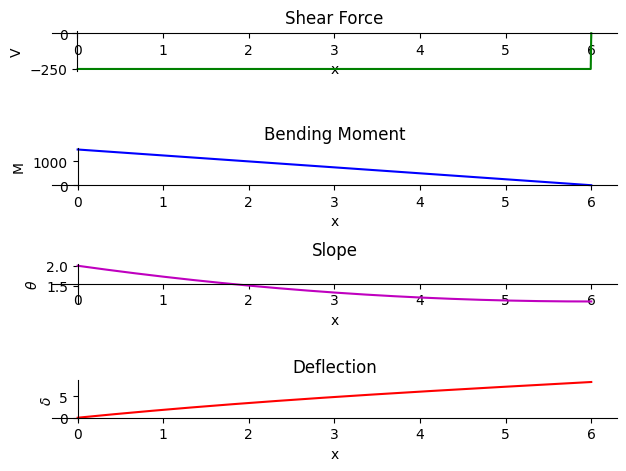

In [1]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols

#Omschrijving van de balk
r0,m0 = symbols(['r0', 'm0'])
b = Beam(6, 500, 10)
b.apply_load(r0, 0, -1)
b.apply_load(m0, 0, -2)
b.apply_load(-250, 6, -1)
b.bc_deflection = [(0,0)]
b.bc_slope = [(0,2)]

#berekeningen
b.solve_for_reaction_loads(r0, m0)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()